In [ ]:
# Check GPU status and availability
!nvidia-smi

Sun Apr  5 11:14:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Verify PyTorch CUDA setup and display GPU information
import torch
print("CUDA available:", torch.cuda.is_is_available())  ##Checks if PyTorch can see and use CUDA (the GPU)
print("Torch CUDA version:", torch.version.cuda) ##Shows which CUDA version your PyTorch installation is using
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None") ##Prints the name of your GPU

CUDA available: True
Torch CUDA version: 12.8
GPU name: Tesla T4


In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Change the current working directory to the data folder on Google Drive
%cd /content/drive/MyDrive/Data

/content/drive/MyDrive/Data


In [3]:
# List the contents of the current directory
!ls

data.yaml	     remap_classes.py  train	   yolov8m_seg_model.pt
README.dataset.txt   runs	       valid	   yolov8m-seg.pt
README.roboflow.txt  test	       yolo26n.pt


In [4]:
# Install the ultralytics library
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.4 MB/s eta 0:00:00


In [ ]:
# Display the content of the data.yaml configuration file
!cat data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['food_classes','plate_classes','utensil_classes','garbage_classes']

roboflow:
  workspace: nothing-ywfuq
  project: leftoverfooddetection-76b5l
  version: 48
  license: CC BY 4.0
  url: https://universe.roboflow.com/nothing-ywfuq/leftoverfooddetection-76b5l/dataset/48

In [ ]:
# Initialize and train a YOLOv8m-seg model
from ultralytics import YOLO

model = YOLO("yolov8m-seg.pt")

model.train(
    data="data.yaml",
    epochs=120,
    imgsz=800,
    batch=16,
    patience=30,
    optimizer="AdamW",
    lr0=0.001,
    cls=3.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.10,
    close_mosaic=10
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ca305967aa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0

## Evaluate Properly

In [ ]:
# Evaluate the trained model on the validation dataset and print key metrics
metrics = model.val()
print("mAP50:", metrics.seg.map50)
print("mAP50-95:", metrics.seg.map)
print("Precision:", metrics.seg.mp)
print("Recall:", metrics.seg.mr)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,224,700 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 37.6±26.3 MB/s, size: 83.4 KB)
val: Scanning /content/drive/MyDrive/Data/valid/labels.cache... 118 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 30.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.5s/it 12.4s
                   all        118        691      0.767      0.642      0.711      0.574      0.717      0.629      0.664      0.465
          food_classes         74        191      0.684      0.577      0.635       0.49      0.637      0.576      0.596      0.458
         plate_classes        112        244      0.824      0.672      0.741      0.609      0.769      0.648      0.682      0.458
       utensil_classes         66 

## Test On One Image


image 1/1 /content/istockphoto-1208968713-612x612.jpg: 736x800 2 food_classess, 4 plate_classess, 2 utensil_classess, 1 garbage_classes, 2823.7ms
Speed: 9.4ms preprocess, 2823.7ms inference, 23.0ms postprocess per image at shape (1, 3, 736, 800)
Results saved to /content/drive/MyDrive/Data/runs/segment/predict13
Detected Objects: 9
utensil_classes (0.89)
utensil_classes (0.86)
food_classes (0.84)
plate_classes (0.83)
plate_classes (0.80)
plate_classes (0.76)
garbage_classes (0.65)
plate_classes (0.59)
food_classes (0.33)


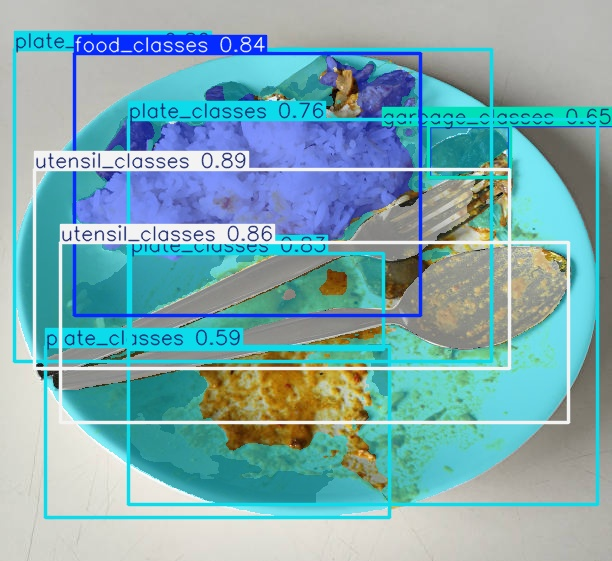

In [7]:
# Perform inference on a single image and display the results
# 1️⃣ Import necessary libraries
from ultralytics import YOLO
from IPython.display import Image, display
import os

# 2️⃣ Load your trained model
model = YOLO("/content/drive/MyDrive/Data/runs/segment/train/weights/best.pt")

# 3️⃣ Define the image path for prediction
image_path = "/content/istockphoto-1208968713-612x612.jpg"

# 4️⃣ Run prediction with specified parameters
results = model.predict(
    source=image_path,
    save=True,
    conf=0.30,
    iou=0.5,
    max_det=20
)

# 5️⃣ Process prediction results, filter weak predictions, and print detected objects
for r in results:
    valid_boxes = []

    for box in r.boxes:
        confidence = float(box.conf)

        # 🔥 filter weak predictions
        if confidence >= 0.25:
            valid_boxes.append(box)

    print("Detected Objects:", len(valid_boxes))

    for box in valid_boxes:
        class_id = int(box.cls)
        class_name = model.names[class_id]
        confidence = float(box.conf)

        print(f"{class_name} ({confidence:.2f})")

# 6️⃣ Display the output image with detections
output_path = results[0].save_dir + "/" + os.path.basename(image_path)
display(Image(filename=output_path))

## Leftover Percentage Calculation

Leftover% = (FoodArea / PlateArea) * 100

In [8]:
# Calculate the leftover food percentage based on detected object masks

import numpy as np

for r in results:

    # Get masks and class IDs from the prediction results
    masks = r.masks.data
    classes = r.boxes.cls

    # Initialize area counters for each class
    food_area = 0
    plate_area = 0
    utensil_area = 0
    garbage_area = 0

    # Loop through each detected object's mask and class
    for mask, cls in zip(masks, classes):
        area = mask.sum().item()  # Calculate the area (number of pixels)
        class_id = int(cls)
        class_name = model.names[class_id]

        print(f"{class_name} area (pixels): {area}")

        # Accumulate area for each class
        if class_name == "food_classes":
            food_area += area

        elif class_name == "plate_classes":
            plate_area += area

        elif class_name == "utensil_classes":
            utensil_area += area

        elif class_name == "waste_classes": # Assuming 'waste_classes' was meant instead of 'garbage_classes' from data.yaml
            garbage_area += area

    print("\n--- Area Summary ---")
    print("Food Area:", food_area)
    print("Plate Area:", plate_area)
    print("Utensil Area:", utensil_area)
    print("Garbage Area:", garbage_area)

    # Calculate leftover percentage, avoiding division by zero
    usable_plate_area = plate_area

    if usable_plate_area > 0:
        leftover_percentage = (food_area / usable_plate_area) * 100
        print(f"\nLeftover Percentage: {leftover_percentage:.2f}%")
    else:
        print("\nCannot calculate leftover (plate not detected properly)")

utensil_classes area (pixels): 23195
utensil_classes area (pixels): 36411
food_classes area (pixels): 86386
plate_classes area (pixels): 12466
plate_classes area (pixels): 70216
plate_classes area (pixels): 83132
garbage_classes area (pixels): 4631
plate_classes area (pixels): 41451
food_classes area (pixels): 4415

--- Area Summary ---
Food Area: 90801
Plate Area: 207265
Utensil Area: 59606
Garbage Area: 0

Leftover Percentage: 43.81%


In [ ]:
# Save the trained YOLOv8 segmentation model to a .pt file

# Removed import pickle as it's not suitable for saving YOLO models directly

# Define the filename for the model weights
model_save_path = "yolov8m_seg_model.pt" # Using .pt extension for Ultralytics models

# Save the model using its built-in save method
model.save(model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to yolov8m_seg_model.pt


In [ ]:
# This commented-out cell shows an attempt to save the model using pickle, but notes that .pt is preferred for Ultralytics models.
# import pickle
# from ultralytics import YOLO

# # Define the filename for the pickle file
# pickle_filename = "yolov8m_seg_model.pkl"

# # Load the model if it's not already loaded (important for standalone execution)
# # Ensure this path points to your trained model's best weights
# model = YOLO("/content/drive/MyDrive/Data/runs/segment/train/weights/best.pt")

# # Save the model using pickle
# with open(pickle_filename, 'wb') as f:
#     pickle.dump(model, f)

# print(f"Model successfully saved as {pickle_filename}")
# print("Note: Ultralytics models are typically saved as .pt files using model.save() for better compatibility and efficiency.")